<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica5Quest%C3%A3o3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imagem: 670 x 1200 = 804000 pixels

  L  r (%) |  K total  % dos coef.  K médio/bloco |        EQM  PSNR (dB)
  8   95.0 |    20329        2.521      1.61 de 64   |  1.288e+02      27.03
  8   50.0 |    12643        1.568      1.00 de 64   |  4.102e+02      22.00
 64   95.0 |     3339        0.390     15.98 de 4096 |  5.841e+02      20.47
 64   50.0 |      218        0.025      1.04 de 4096 |  2.370e+03      14.38


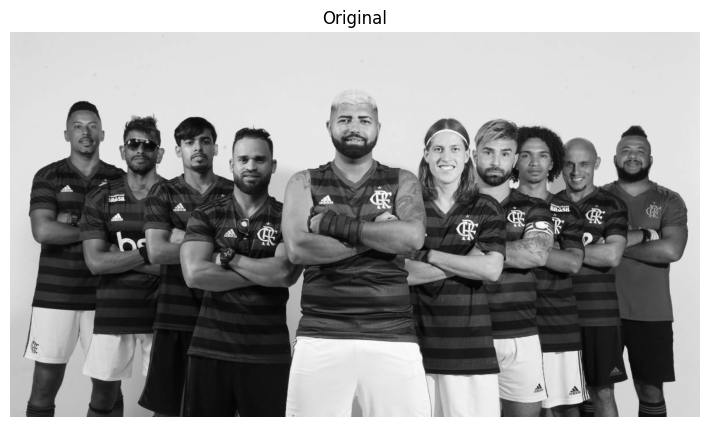

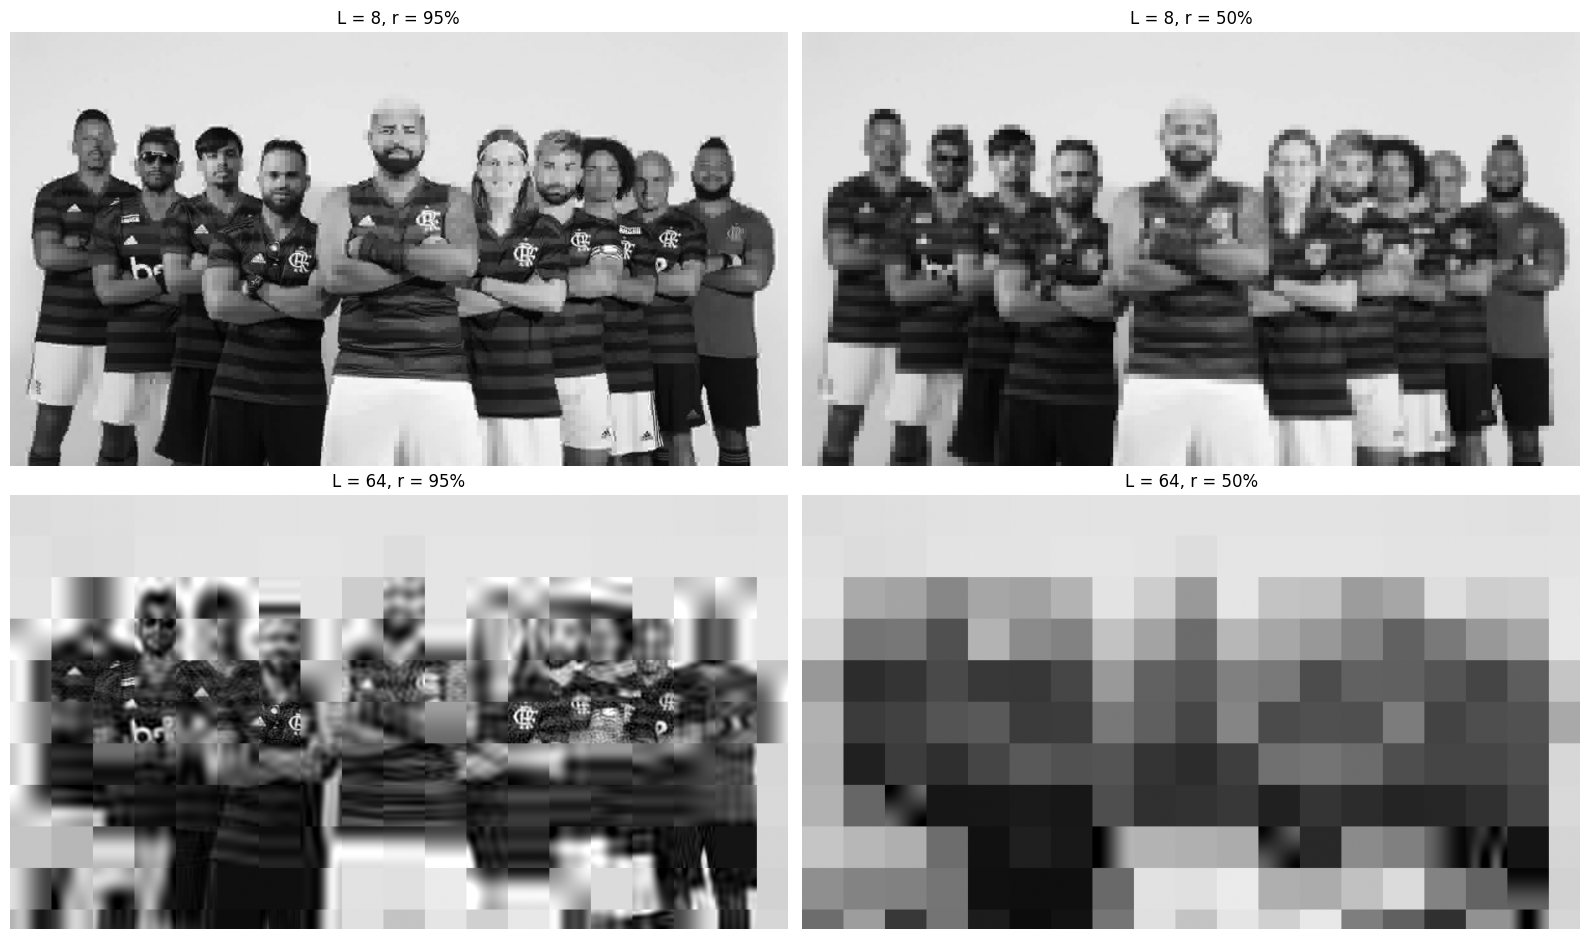

In [1]:
!wget -q -O sosias.jpg "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_05/Imagens_Usadas/sosias.jpg"

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fft import dctn, idctn

img = np.asarray(Image.open("sosias.jpg").convert("L"), dtype=float)
M, N = img.shape
print(f"Imagem: {M} x {N} = {M*N} pixels\n")

def comprime_blocos(img, L, r):
    M, N = img.shape
    # completa a imagem (repetindo a borda) até um múltiplo de L
    Mp, Np = -(-M // L) * L, -(-N // L) * L
    x = np.pad(img, ((0, Mp - M), (0, Np - N)), mode="edge")

    # separa em blocos L x L e aplica a DCT 2-D em cada um
    B = x.reshape(Mp // L, L, Np // L, L).swapaxes(1, 2).reshape(-1, L, L)
    C = dctn(B, axes=(1, 2), norm="ortho").reshape(-1, L * L)

    # em cada bloco: menor nº de coeficientes que atinge r da energia do bloco
    e = C ** 2
    es = np.sort(e, axis=1)[:, ::-1]
    acum = np.cumsum(es, axis=1)
    Eb = acum[:, -1:]
    k = np.minimum((acum < r * Eb).sum(axis=1), L * L - 1)
    limiar = es[np.arange(len(es)), k][:, None]
    mask = (e >= limiar) & (Eb > 0)

    # reconstrói
    Br = idctn((C * mask).reshape(-1, L, L), axes=(1, 2), norm="ortho")
    xr = Br.reshape(Mp // L, Np // L, L, L).swapaxes(1, 2).reshape(Mp, Np)[:M, :N]
    return xr, mask.sum(), mask.size, mask.sum(axis=1).mean()

casos = [(8, 0.95), (8, 0.50), (64, 0.95), (64, 0.50)]
rec = {}
print(f"{'L':>3} {'r (%)':>6} | {'K total':>8} {'% dos coef.':>12} {'K médio/bloco':>14} | {'EQM':>10} {'PSNR (dB)':>10}")
for L, r in casos:
    xr, K, tot, Kmed = comprime_blocos(img, L, r)
    eqm = np.mean((img - xr) ** 2)
    rec[L, r] = xr
    print(f"{L:3d} {100*r:6.1f} | {K:8d} {100*K/tot:12.3f} {Kmed:9.2f} de {L*L:<4d} | "
          f"{eqm:10.3e} {10*np.log10(255**2/eqm):10.2f}")

# ---------- Imagens ----------
plt.figure(figsize=(9, 5))
plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off"); plt.show()

fig, ax = plt.subplots(2, 2, figsize=(16, 9.5))
for a, (L, r) in zip(ax.ravel(), casos):
    a.imshow(rec[L, r], cmap="gray", vmin=0, vmax=255)
    a.set_title(f"L = {L}, r = {100*r:.0f}%"); a.axis("off")
plt.tight_layout(); plt.show()


A imagem foi comprimida em blocos L × L, mantendo em cada bloco os coeficientes da DCT de maior energia até atingir a fração r da energia do bloco.

Com r = 50%, praticamente todo bloco fica apenas com o coeficiente DC, pois o brilho médio já concentra mais da metade da energia do bloco. A imagem reconstruída é formada por blocos de intensidade constante, o que equivale a reduzir a resolução por um fator L. Para L = 8 (12 643 coeficientes, 1,57% do total, EQM = 4,10·10²) a imagem ainda é reconhecível, mas com aspecto de mosaico. Para L = 64 restam apenas 218 coeficientes (0,025%), com o maior erro de todos (EQM = 2,37·10³) e perda quase total dos detalhes.

Com r = 95%, o número de coeficientes se adapta ao conteúdo: blocos lisos continuam só com o DC, enquanto blocos com bordas e texturas recebem mais. Para L = 8, com média de apenas 1,61 coeficiente por bloco (20 329 no total, 2,52%), a imagem fica próxima da original, com leve efeito de bloco, e tem o menor erro (EQM = 1,29·10², PSNR de 27 dB). Para L = 64 são mantidos menos coeficientes (3 339, 0,39%), mas o erro é 4,5 vezes maior (EQM = 5,84·10²), pois em blocos grandes as baixas frequências dominam a energia e os detalhes finos são descartados.

Portanto, para um mesmo r, o bloco maior usa menos coeficientes, porém com erro maior e pior qualidade. O bloco pequeno aplica o critério de energia localmente, preservando os detalhes de cada região. Isso explica a diferença em relação à compressão da imagem inteira, em que mesmo 99% da energia resultava em uma imagem degradada, e justifica o uso de blocos 8 × 8 no JPEG.